In [16]:
import tensorly as tl

tl.get_backend()

'cupy'

In [18]:
from moabb.paradigms import P300
from moabb.datasets import *
from mne.decoding import Scaler
tmin = 0
tmax=0.8
fmin=0.5
fmax = 16
sfreq = 32

paradigm = P300(resample=sfreq, tmin=tmin, tmax=tmax, fmin=fmin, fmax=fmax)
dataset = BNCI2014_009()
epochs, labels, meta = paradigm.get_data(dataset=dataset, 
                                         subjects=[1],
                                         return_epochs=True)
idc = meta['session'] == meta['session'][0]
epochs = epochs[idc]
labels = labels[idc]
meta = meta[idc]
epochs._data = Scaler(scalings='mean', with_mean=True).fit_transform(epochs._data)

Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
1728 matching events found
No baseline correction applied


/usr/local/lib/python3.10/dist-packages/moabb/paradigms/base.py:354: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  X = mne.concatenate_epochs(X)


In [19]:
epochs

Number of events,576
Events,NonTarget: 480Target: 96
Time range,0.000 – 0.781 s
Baseline,off


In [20]:
meta

,subject,session,run
0,1,0,0
1,1,0,0
2,1,0,0
3,1,0,0
4,1,0,0
...,...,...,...
571,1,0,0
572,1,0,0
573,1,0,0
574,1,0,0


In [21]:
from hoda.tensorize import hankel_tensor
X = epochs.get_data()
y = labels
print(X.shape)
X = hankel_tensor(X)
X.shape

(576, 16, 26)


/tmp/ipykernel_60/2316430803.py:2: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  X = epochs.get_data()


(576, 16, 14, 13)

In [29]:
from hoda.hoda import BTTDA


bttda = BTTDA(
    ranks=[None]*16,    
    hoda_params=dict(
            max_iter=256,
            tol=1e-8,
            init ='mlsvd',
            shrinkage='lw',
            toeplitz=(1,2,),
            taper=False,
            obj='rt',
            solver='lanczos',
            extra_train_info=False,
            verbose=True,
            delta=0.1,
    ),
    verbose=False,
    extra_train_info=True,
)

bttda.fit(X,y)

  0%|          | 0/256 [00:00<?, ?it/s]

Fit discriminative tensor model of rank (2, 3, 3)...


  0%|          | 0/256 [00:00<?, ?it/s]

Fit discriminative tensor model of rank (2, 3, 3)...


  0%|          | 0/256 [00:00<?, ?it/s]

...

  0%|          | 0/256 [00:00<?, ?it/s]

Fit discriminative tensor model of rank (2, 2, 2)...


  0%|          | 0/256 [00:00<?, ?it/s]

Fit discriminative tensor model of rank (2, 2, 2)...


BTTDA(extra_train_info=True,
      hoda_params={'delta': 0.1, 'extra_train_info': False, 'init': 'mlsvd',
                   'max_iter': 256, 'obj': 'rt', 'rank': None,
                   'shrinkage': 'lw', 'solver': 'lanczos', 'taper': False,
                   'toeplitz': (1, 2), 'tol': 1e-08, 'verbose': True},
      ranks=[None, None, None, None, None, None, None, None, None, None, None,
             None, None, None, None, None])

In [30]:
import pandas as pd

pd.DataFrame(bttda.train_info_)

,block,rank,F_tr,F_rt,mse
0,1,"(2, 3, 3)",0.324712,0.006772,0.944876
1,2,"(2, 3, 3)",0.298750,0.008517,0.914214
2,3,"(2, 3, 3)",0.275198,0.009582,0.904694
3,4,"(2, 4, 4)",0.249939,0.010081,0.890462
4,5,"(3, 3, 3)",0.249637,0.010274,0.900815
5,6,"(3, 3, 3)",0.244124,0.010766,0.891667
6,7,"(1, 1, 1)",0.360158,0.010918,0.890669
7,8,"(2, 2, 2)",0.361886,0.011121,0.946268
8,9,"(1, 1, 1)",0.364977,0.011132,0.946361
9,10,"(1, 1, 1)",0.512513,0.011131,0.940802


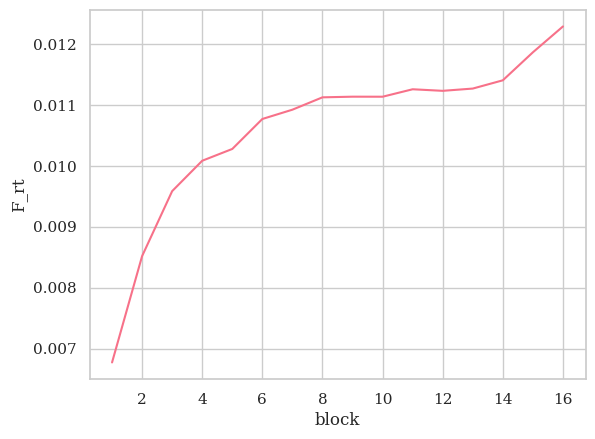

<Axes: xlabel='block', ylabel='mse'>

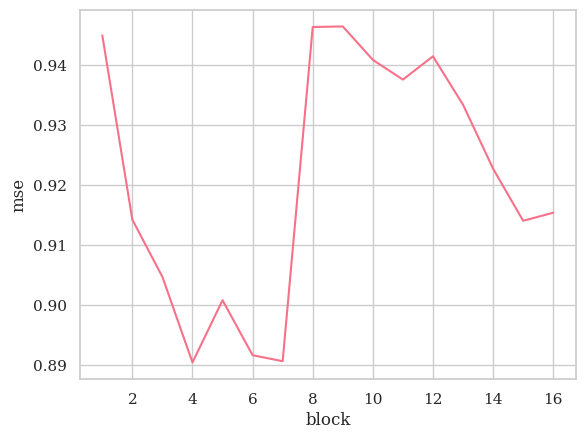

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.lineplot(data=bttda.train_info_, x='block', y='F_rt')
plt.show()
sns.lineplot(data=bttda.train_info_, x='block', y='mse')

No projector specified for this dataset. Please consider the method self.add_proj.


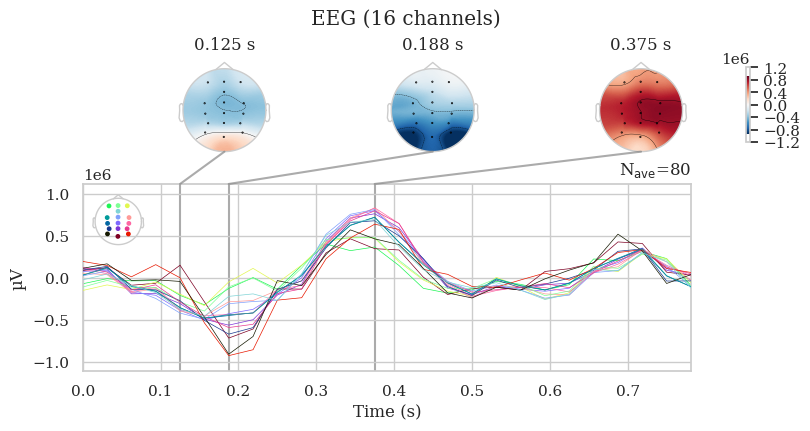

In [32]:
from mne import combine_evoked
import numpy as np
target = epochs['Target'].average()
non_target = epochs['NonTarget'].average()
contrast = combine_evoked([target,non_target], weights=[1,-1])
vmax = np.max(np.abs(contrast.data))*1.2*1e6
joint_args=dict(ts_args=dict(ylim=dict(eeg=[-vmax, vmax])))
_ = contrast.plot_joint(**joint_args)

No projector specified for this dataset. Please consider the method self.add_proj.


/tmp/ipykernel_60/3955356239.py:7: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  X_defl = hankel_tensor(epochs.get_data())
/tmp/ipykernel_60/3955356239.py:9: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  epochs_rec._data = np.zeros_like(epochs_rec.get_data())


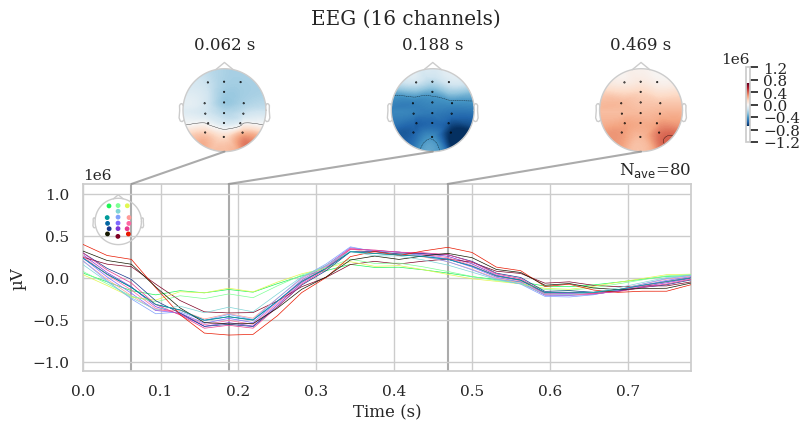

No projector specified for this dataset. Please consider the method self.add_proj.


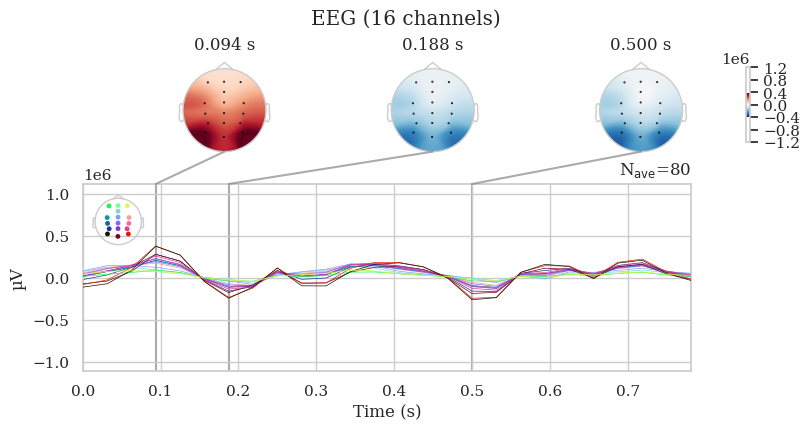

No projector specified for this dataset. Please consider the method self.add_proj.


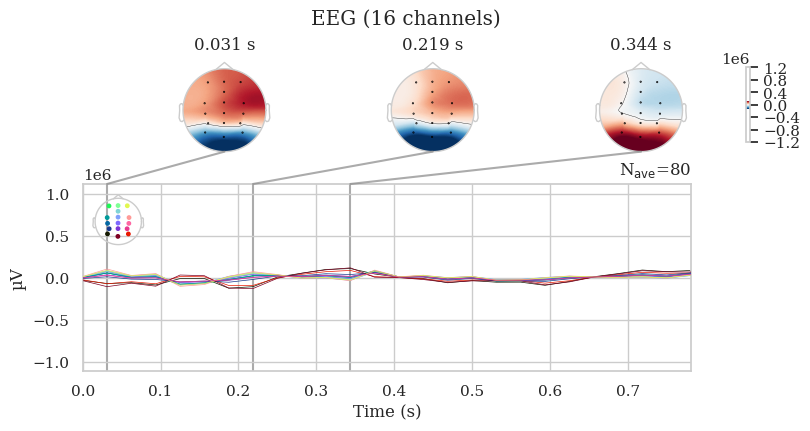

No projector specified for this dataset. Please consider the method self.add_proj.


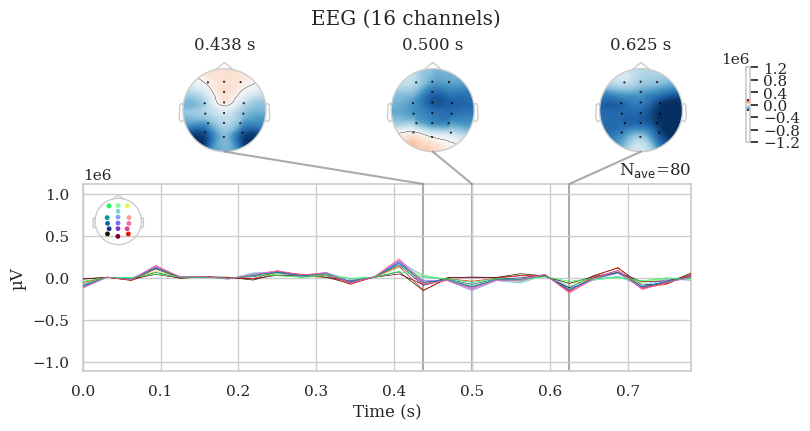

No projector specified for this dataset. Please consider the method self.add_proj.


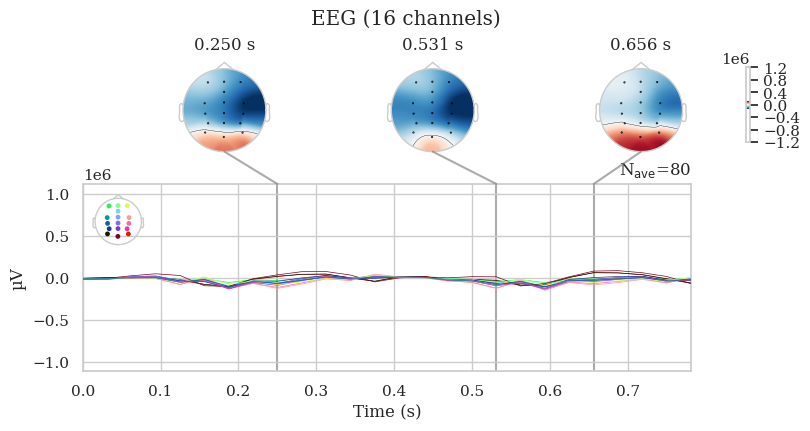

No projector specified for this dataset. Please consider the method self.add_proj.


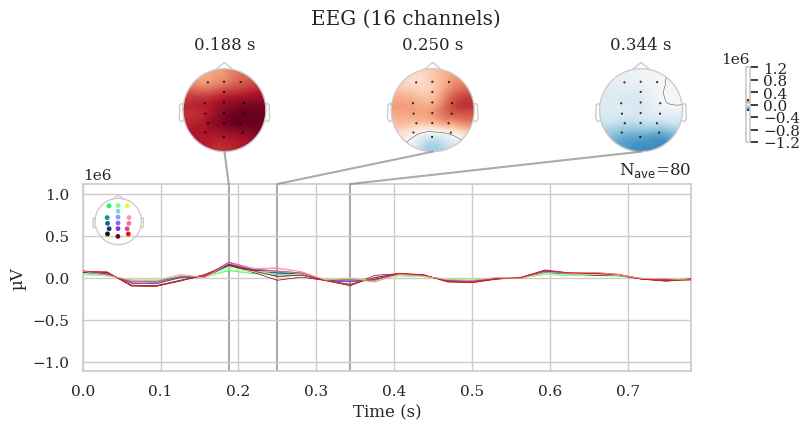

No projector specified for this dataset. Please consider the method self.add_proj.


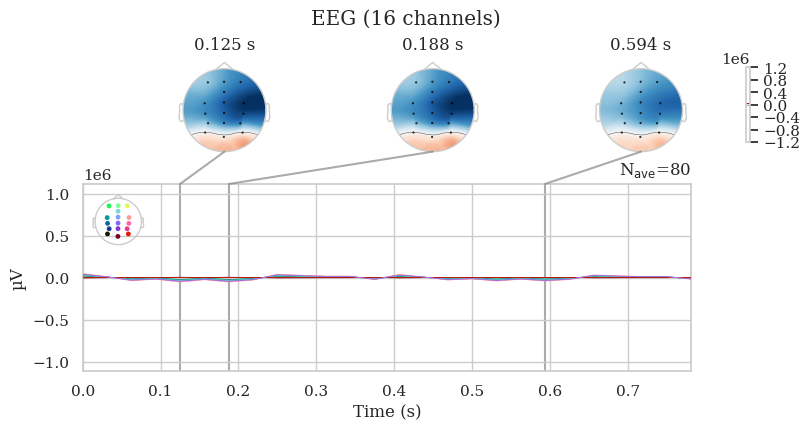

No projector specified for this dataset. Please consider the method self.add_proj.


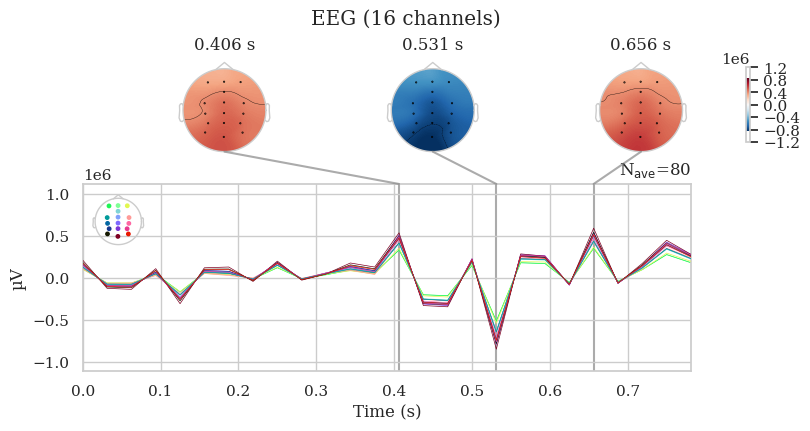

No projector specified for this dataset. Please consider the method self.add_proj.


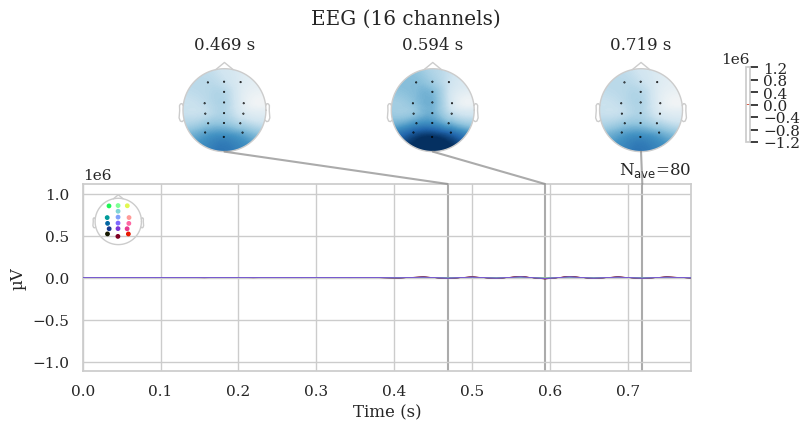

No projector specified for this dataset. Please consider the method self.add_proj.


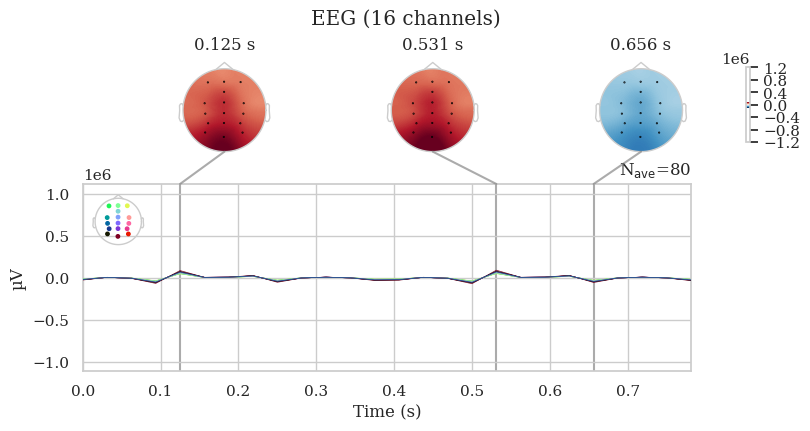

No projector specified for this dataset. Please consider the method self.add_proj.


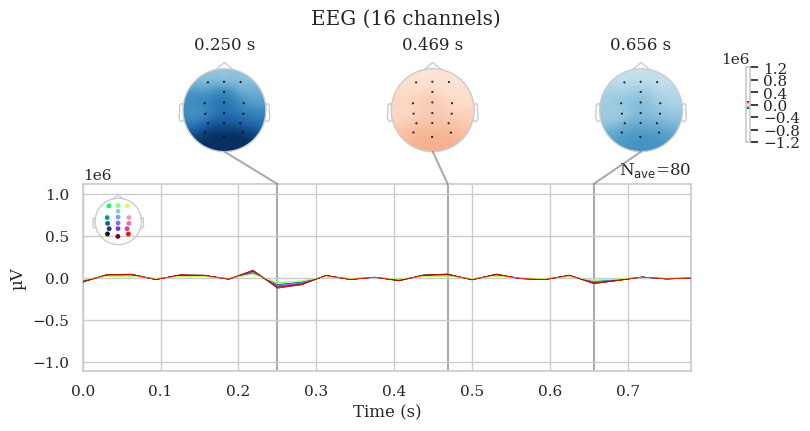

No projector specified for this dataset. Please consider the method self.add_proj.


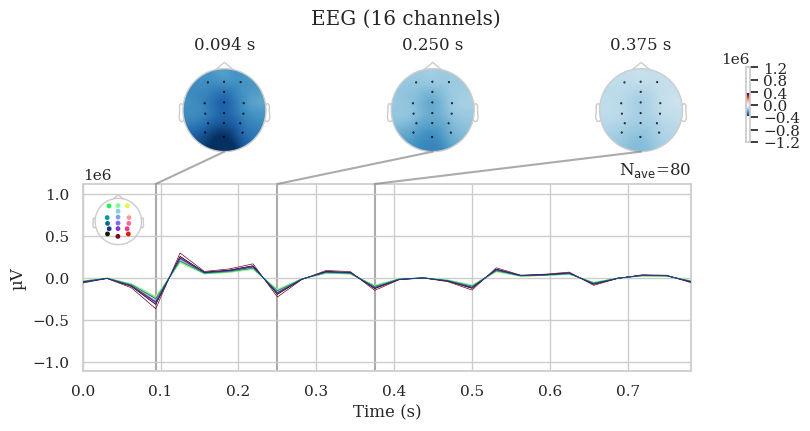

No projector specified for this dataset. Please consider the method self.add_proj.


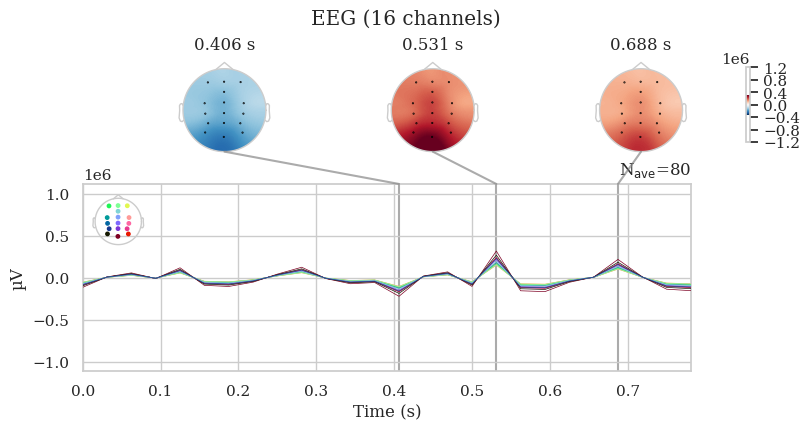

No projector specified for this dataset. Please consider the method self.add_proj.


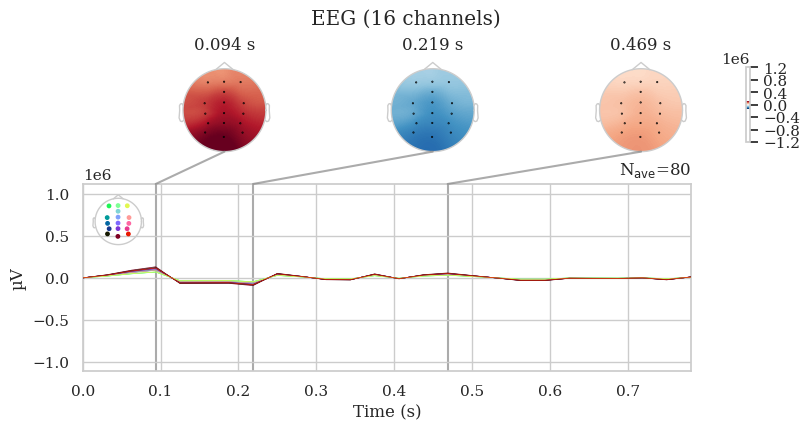

No projector specified for this dataset. Please consider the method self.add_proj.


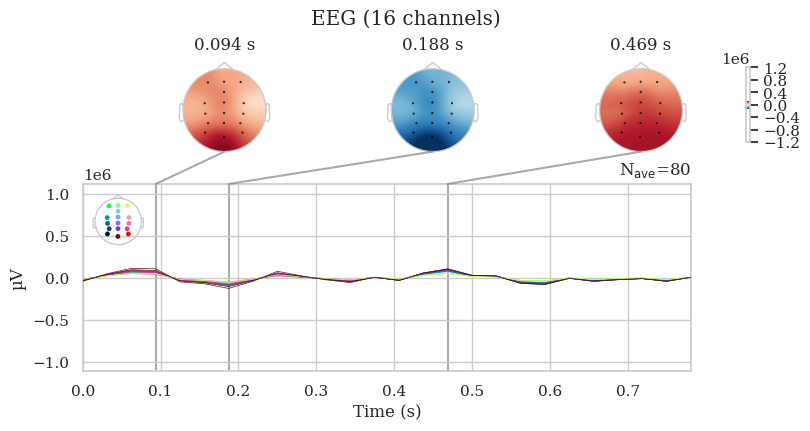

No projector specified for this dataset. Please consider the method self.add_proj.


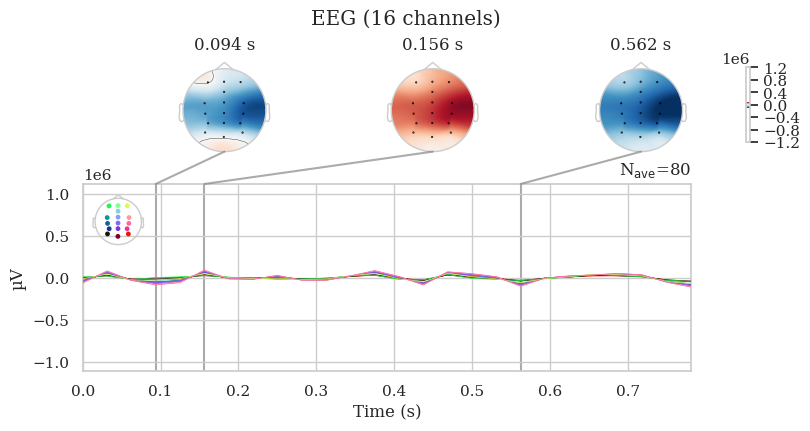

In [33]:
from mne import combine_evoked
from mne.viz import plot_compare_evokeds
from hoda.tensorize import hankel_tensor_inv
import numpy as np


X_defl = hankel_tensor(epochs.get_data())
epochs_rec = epochs.copy()
epochs_rec._data = np.zeros_like(epochs_rec.get_data())
evokeds = dict()
for b in range(len(bttda.blocks_)):
    epochs_block_rec = epochs.copy()
    Xb =  tl.to_numpy(bttda.blocks_[b].inv_transform(bttda.blocks_[b].transform(X_defl)))
    epochs_block_rec._data =hankel_tensor_inv(Xb)
    X_defl -= Xb
    epochs_rec._data += epochs_block_rec._data
    
    target_block_rec = epochs_block_rec['Target'].average()
    non_target_block_rec = epochs_block_rec['NonTarget'].average()
    contrast_block_rec = combine_evoked([target_block_rec,non_target_block_rec], weights=[1,-1])
    evokeds[f'block {b}'] =contrast_block_rec
    contrast_block_rec.plot_joint(**joint_args)